In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import  LinearRegression,Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor


In [2]:
df=pd.read_csv('house_price_data.csv')

In [3]:
df

,Area_sqft,Bedrooms,Bathrooms,House_Age,Garage_Cars,Floors,Location_Score,School_Rating,Distance_to_City_km,Crime_Rate,Price
0,1360,2,2,13,3,1,4.6,1.8,5.0,7.58,295600
1,4272,3,4,26,2,2,5.0,2.8,11.7,4.89,796200
2,3592,1,1,40,2,1,9.0,5.9,13.3,1.21,655500
3,966,6,3,39,0,2,6.9,2.9,41.8,1.24,187700
4,4926,1,3,27,3,2,1.1,5.9,23.7,8.04,736200
...,...,...,...,...,...,...,...,...,...,...,...
995,3261,4,1,15,2,2,1.7,9.1,24.7,4.87,559200
996,3179,2,3,42,0,2,6.2,1.0,33.3,5.76,503200
997,2606,1,2,35,0,1,8.7,6.3,26.0,8.27,471000
998,4723,5,4,12,2,1,7.5,7.5,24.4,2.82,877100


In [4]:
print("shape:",df.shape)
print("\nFirst 5 rows:")
df.head()


shape: (1000, 11)

First 5 rows:


,Area_sqft,Bedrooms,Bathrooms,House_Age,Garage_Cars,Floors,Location_Score,School_Rating,Distance_to_City_km,Crime_Rate,Price
0,1360,2,2,13,3,1,4.6,1.8,5.0,7.58,295600
1,4272,3,4,26,2,2,5.0,2.8,11.7,4.89,796200
2,3592,1,1,40,2,1,9.0,5.9,13.3,1.21,655500
3,966,6,3,39,0,2,6.9,2.9,41.8,1.24,187700
4,4926,1,3,27,3,2,1.1,5.9,23.7,8.04,736200


In [5]:
df.info

<bound method DataFrame.info of      Area_sqft  Bedrooms  Bathrooms  House_Age  Garage_Cars  Floors  \
0         1360         2          2         13            3       1   
1         4272         3          4         26            2       2   
2         3592         1          1         40            2       1   
3          966         6          3         39            0       2   
4         4926         1          3         27            3       2   
..         ...       ...        ...        ...          ...     ...   
995       3261         4          1         15            2       2   
996       3179         2          3         42            0       2   
997       2606         1          2         35            0       1   
998       4723         5          4         12            2       1   
999       3268         1          4          6            3       1   

     Location_Score  School_Rating  Distance_to_City_km  Crime_Rate   Price  
0               4.6            1.8   

In [6]:
df.isnull().sum()

Area_sqft              0
Bedrooms               0
Bathrooms              0
House_Age              0
Garage_Cars            0
Floors                 0
Location_Score         0
School_Rating          0
Distance_to_City_km    0
Crime_Rate             0
Price                  0
dtype: int64

In [7]:
df.describe().round()

,Area_sqft,Bedrooms,Bathrooms,House_Age,Garage_Cars,Floors,Location_Score,School_Rating,Distance_to_City_km,Crime_Rate,Price
count,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
mean,2815.0,3.0,3.0,25.0,1.0,2.0,5.0,5.0,25.0,5.0,525585.0
std,1256.0,2.0,1.0,14.0,1.0,1.0,3.0,3.0,14.0,3.0,197729.0
min,503.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,71600.0
25%,1750.0,2.0,2.0,12.0,0.0,1.0,3.0,3.0,14.0,3.0,356675.0
50%,2862.0,3.0,2.0,25.0,1.0,2.0,5.0,5.0,26.0,5.0,535650.0
75%,3850.0,5.0,4.0,37.0,2.0,3.0,8.0,8.0,37.0,8.0,672950.0
max,4999.0,6.0,4.0,49.0,3.0,3.0,10.0,10.0,50.0,10.0,991400.0


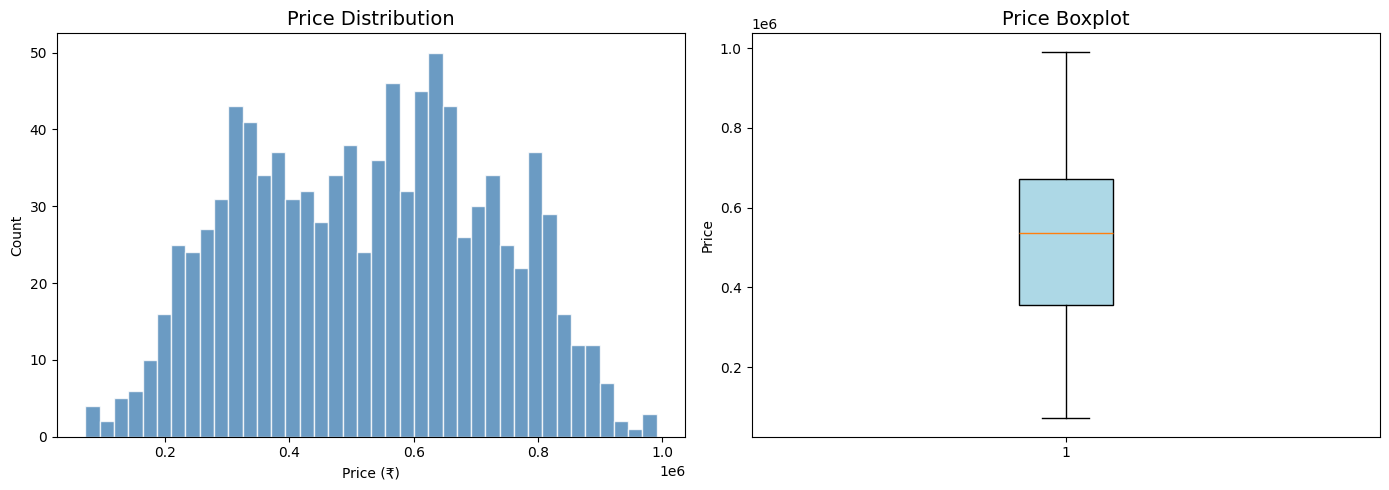

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Price'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Price Distribution', fontsize=14)
axes[0].set_xlabel('Price (₹)')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['Price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Price Boxplot', fontsize=14)
axes[1].set_ylabel('Price')

plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

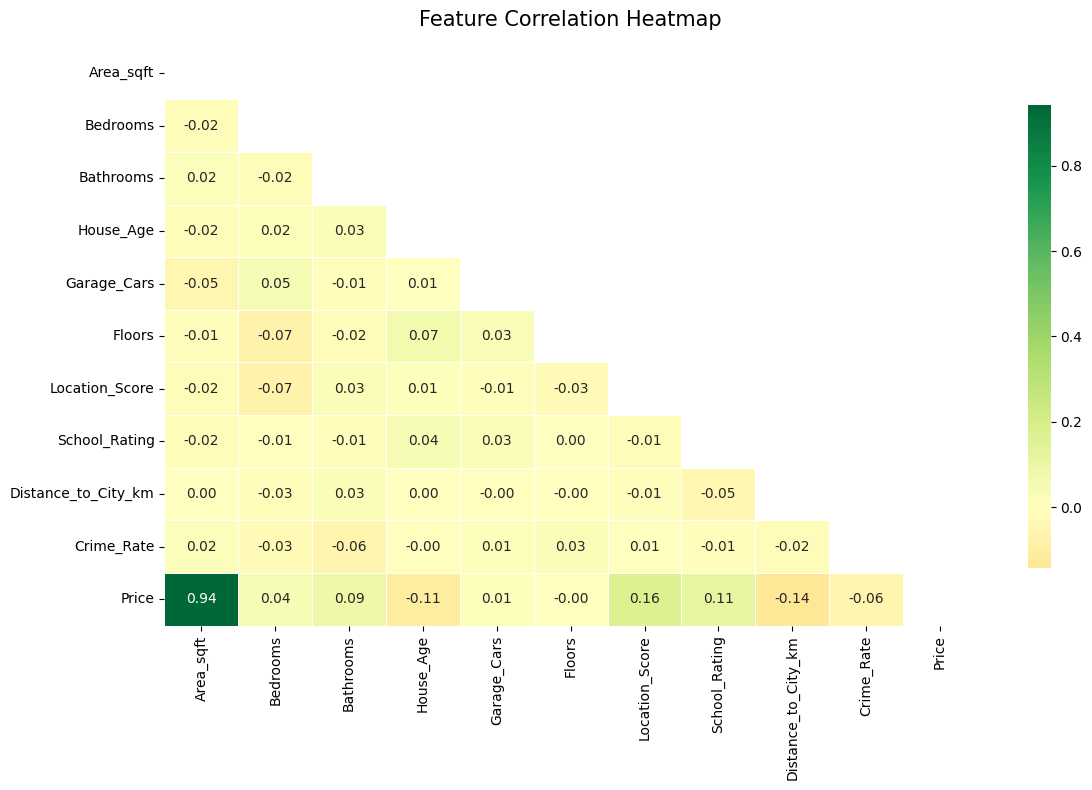

In [9]:
plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=15, pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

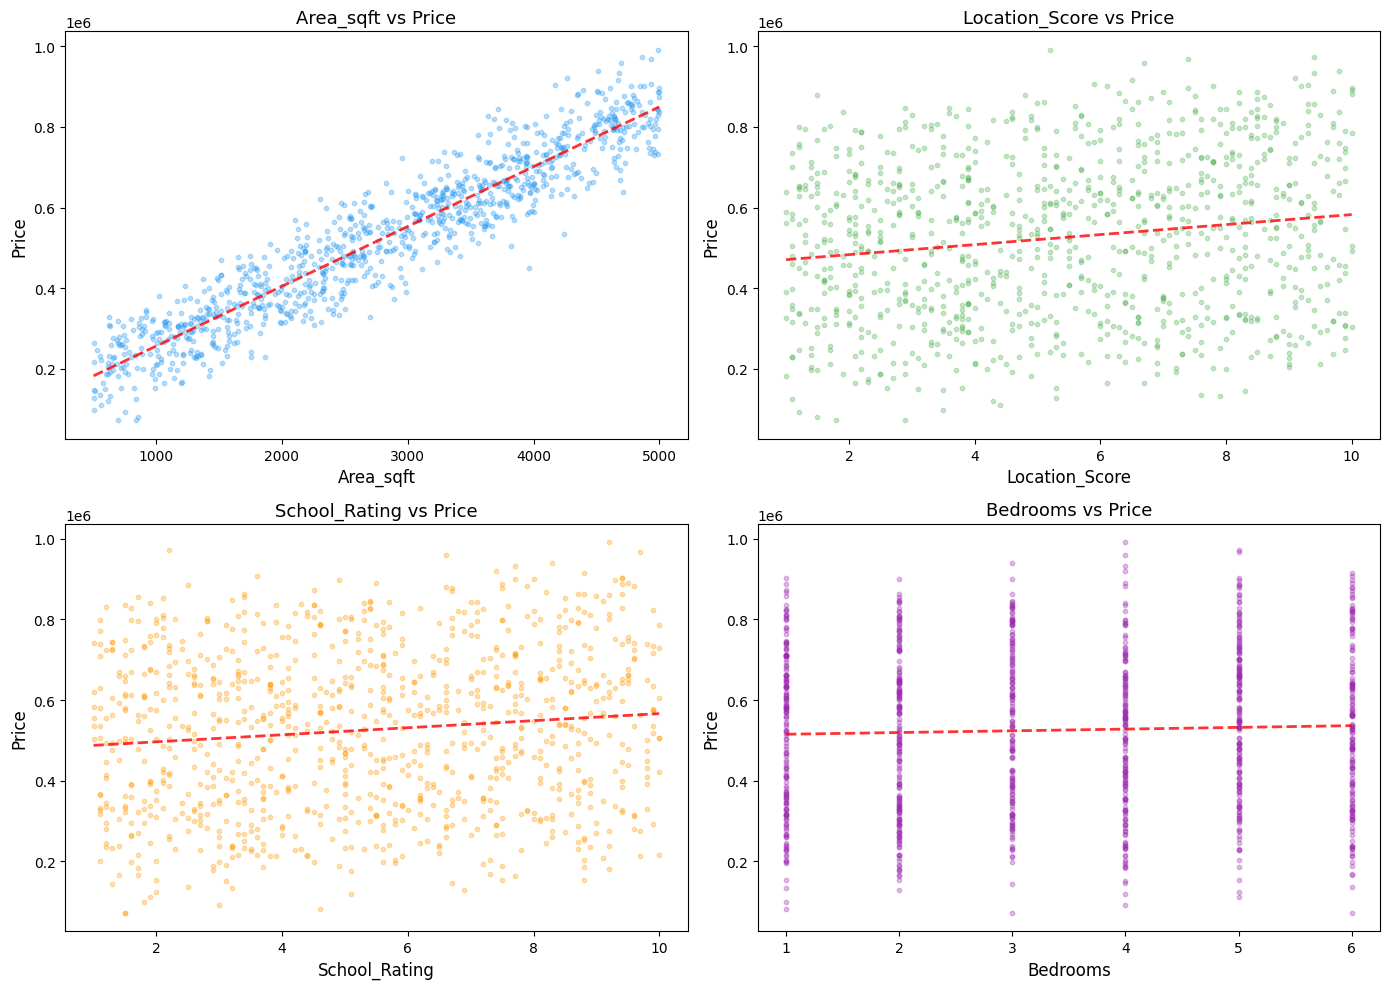

In [10]:
top_features = ['Area_sqft', 'Location_Score', 'School_Rating', 'Bedrooms']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
for i, feat in enumerate(top_features):
    axes[i].scatter(df[feat], df['Price'], alpha=0.3, s=10, color=colors[i])
    axes[i].set_xlabel(feat, fontsize=12)
    axes[i].set_ylabel('Price', fontsize=12)
    axes[i].set_title(f'{feat} vs Price', fontsize=13)
    # Trend line
    z = np.polyfit(df[feat], df['Price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r--', alpha=0.8, linewidth=2)

plt.tight_layout()
plt.savefig('features_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
X = df.drop('Price', axis=1)
y = df['Price']

print("Features:", list(X.columns))
print("Target: Price")
print("\nX shape:", X.shape)
print("y shape:", y.shape)

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n✅ Train size: {X_train.shape[0]} samples")
print(f"✅ Test size:  {X_test.shape[0]} samples")

# Feature Scaling (Linear/Ridge ke liye)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Features: ['Area_sqft', 'Bedrooms', 'Bathrooms', 'House_Age', 'Garage_Cars', 'Floors', 'Location_Score', 'School_Rating', 'Distance_to_City_km', 'Crime_Rate']
Target: Price

X shape: (1000, 10)
y shape: (1000,)

✅ Train size: 800 samples
✅ Test size:  200 samples


In [12]:
models = {
    'Linear Regression': (LinearRegression(), True),   # True = scaled data use karo
    'Ridge Regression':  (Ridge(alpha=1.0),   True),
    'XGBoost':           (XGBRegressor(n_estimators=200,
                                        learning_rate=0.1,
                                        max_depth=6,
                                        random_state=42), False)  # False = original data
}

results = {}
predictions = {}

for name, (model, use_scaled) in models.items():
    X_tr = X_train_sc if use_scaled else X_train
    X_te = X_test_sc  if use_scaled else X_test
    
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    predictions[name] = preds
    
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"{'✅' if r2 > 0.8 else '📊'} {name:20s} | MAE: {mae:>10,.0f} | RMSE: {rmse:>10,.0f} | R²: {r2:.4f}")


✅ Linear Regression    | MAE:     16,779 | RMSE:     20,814 | R²: 0.9895
✅ Ridge Regression     | MAE:     16,761 | RMSE:     20,793 | R²: 0.9895
✅ XGBoost              | MAE:     29,217 | RMSE:     36,053 | R²: 0.9685


                        MAE      RMSE    R2
Linear Regression  16779.01  20813.77  0.99
Ridge Regression   16761.12  20793.25  0.99
XGBoost            29217.04  36053.41  0.97


C:\Users\hp\AppData\Local\Temp\ipykernel_10212\1236155415.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(results.keys()), rotation=15, ha='right')
C:\Users\hp\AppData\Local\Temp\ipykernel_10212\1236155415.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(results.keys()), rotation=15, ha='right')
C:\Users\hp\AppData\Local\Temp\ipykernel_10212\1236155415.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(results.keys()), rotation=15, ha='right')


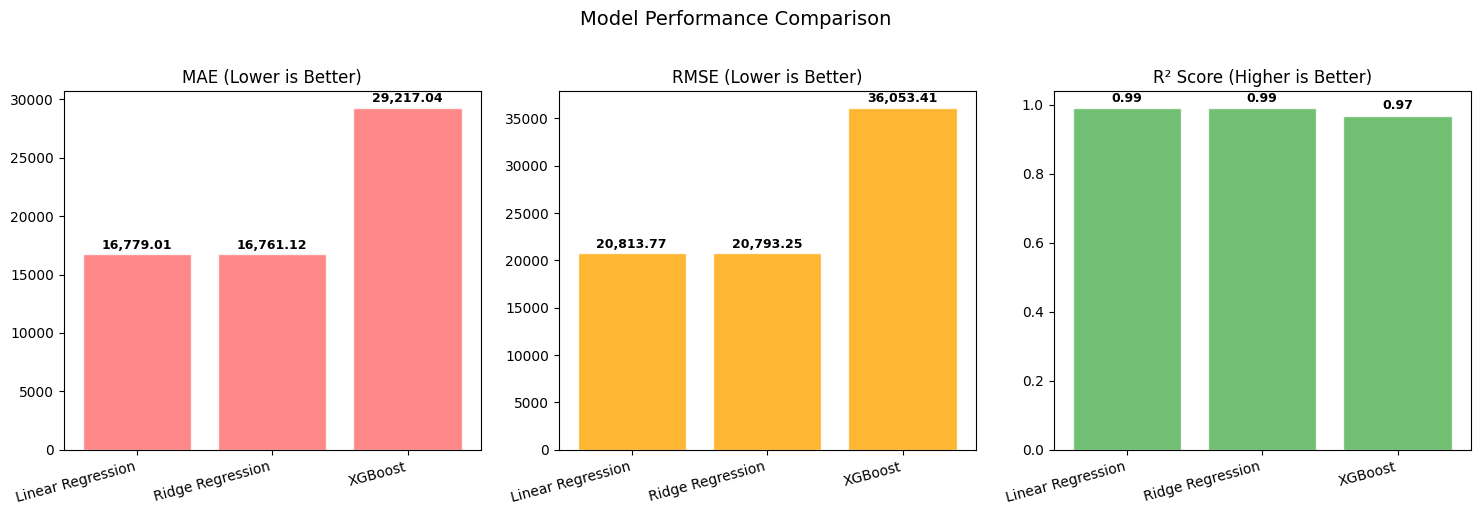

In [13]:
results_df = pd.DataFrame(results).T
print(results_df.round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['MAE', 'RMSE', 'R2']
colors_bar = ['#FF6B6B', '#FFA500', '#4CAF50']
titles = ['MAE (Lower is Better)', 'RMSE (Lower is Better)', 'R² Score (Higher is Better)']

for ax, metric, color, title in zip(axes, metrics, colors_bar, titles):
    vals = [results[m][metric] for m in results]
    bars = ax.bar(list(results.keys()), vals, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(title, fontsize=12)
    ax.set_xticklabels(list(results.keys()), rotation=15, ha='right')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                f'{val:,.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

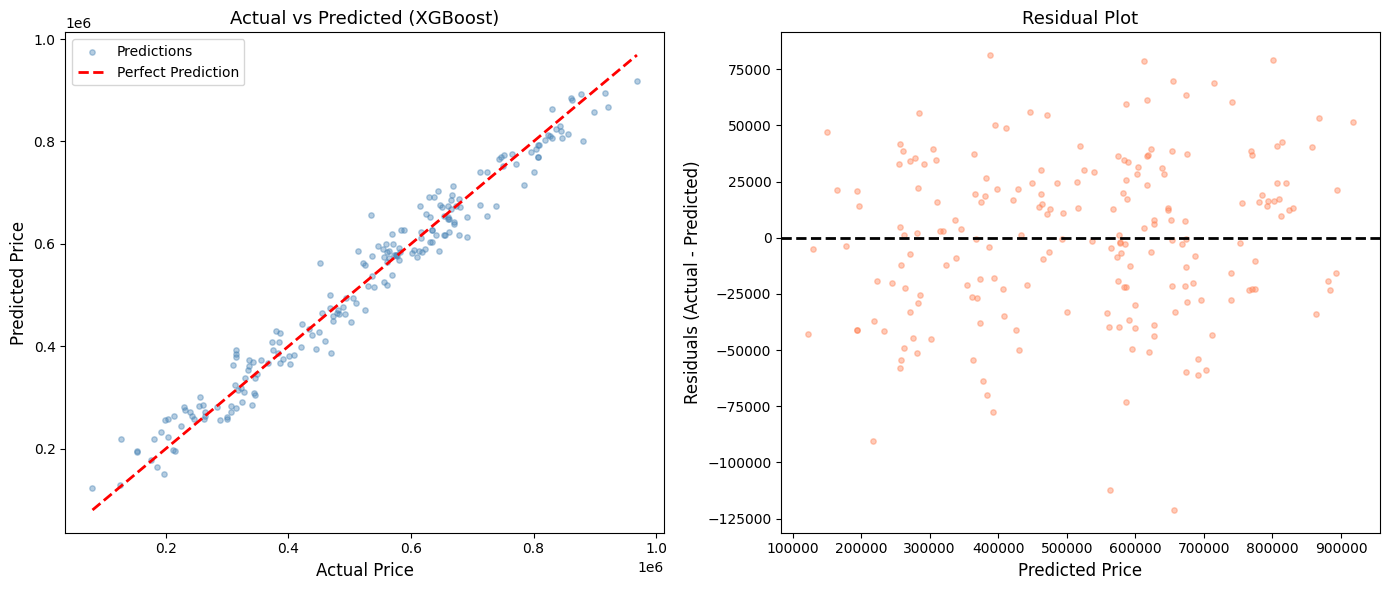

In [14]:
best_preds = predictions['XGBoost']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot
axes[0].scatter(y_test, best_preds, alpha=0.4, s=15, color='steelblue', label='Predictions')
perfect_line = [y_test.min(), y_test.max()]
axes[0].plot(perfect_line, perfect_line, 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price', fontsize=12)
axes[0].set_ylabel('Predicted Price', fontsize=12)
axes[0].set_title('Actual vs Predicted (XGBoost)', fontsize=13)
axes[0].legend()

# Residuals
residuals = y_test.values - best_preds
axes[1].scatter(best_preds, residuals, alpha=0.4, s=15, color='coral')
axes[1].axhline(y=0, color='black', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price', fontsize=12)
axes[1].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
axes[1].set_title('Residual Plot', fontsize=13)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
r2 = results['XGBoost']['R2']

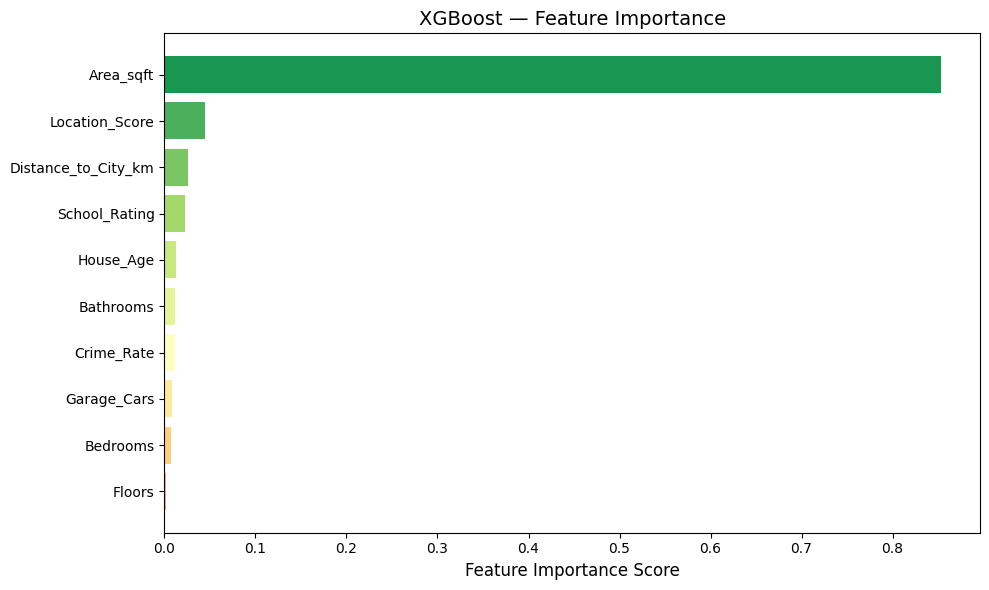

In [15]:
xgb_model = list(models['XGBoost'])
xgb_model = models['XGBoost'][0]

importances = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors_fi = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(importances)))
bars = plt.barh(importances.index, importances.values, color=colors_fi)
plt.xlabel('Feature Importance Score', fontsize=12)
plt.title('XGBoost — Feature Importance', fontsize=14)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
import pickle

# Best model save karo
with open('house_price_model.pkl', 'wb') as f:
    pickle.dump(models['XGBoost'][0], f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Model saved: house_price_model.pkl")
print("✅ Scaler saved: scaler.pkl")

✅ Model saved: house_price_model.pkl
✅ Scaler saved: scaler.pkl


In [17]:
new_house = pd.DataFrame({
    'Area_sqft':           [2000],
    'Bedrooms':            [3],
    'Bathrooms':           [2],
    'House_Age':           [10],
    'Garage_Cars':         [2],
    'Floors':              [2],
    'Location_Score':      [7.5],
    'School_Rating':       [8.0],
    'Distance_to_City_km': [15.0],
    'Crime_Rate':          [2.5]
})

xgb_model = models['XGBoost'][0]
predicted_price = xgb_model.predict(new_house)[0]

print("🏠 New House Details:")
for col, val in zip(new_house.columns, new_house.values[0]):
    print(f"   {col:25s}: {val}")

print(f"\n💰 Predicted Price: ₹{predicted_price:,.0f}")
print(f"   (approx. ${predicted_price/83:,.0f} USD)")

🏠 New House Details:
   Area_sqft                : 2000.0
   Bedrooms                 : 3.0
   Bathrooms                : 2.0
   House_Age                : 10.0
   Garage_Cars              : 2.0
   Floors                   : 2.0
   Location_Score           : 7.5
   School_Rating            : 8.0
   Distance_to_City_km      : 15.0
   Crime_Rate               : 2.5

💰 Predicted Price: ₹497,612
   (approx. $5,995 USD)
